# 1. Final Basic DLinear


## 1. Imports and experiment settings

General settings shared by every final model so the results can be compared

In [1]:
import itertools
import json
import sys
from pathlib import Path
from types import SimpleNamespace

import matplotlib.pyplot as plt
import pandas as pd
import torch

PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "final":
    PROJECT_ROOT = PROJECT_ROOT.parent.parent
elif PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from models.DLinear import Model as DLinear
from settings.final_config import (
    BATCH_SIZE,
    EVAL_GROUPS,
    FINAL_SEEDS,
    GRID,
    PRED_LEN,
    RESULT_ROOT,
    SEARCH_SEED,
    SEARCH_TRAIN_END_IDX,
    TEST_END_IDX,
    TEST_START_IDX,
    VALIDATION_END_IDX,
    VALIDATION_START_IDX,
)
from settings.final_data import (
    build_forecast_data,
    build_split_ids,
    build_train_loader,
    load_existing_split,
    load_preprocessors,
    load_series_arrays,
    select_loaded_series,
)
from settings.final_evaluation import (
    create_per_series_metrics,
    create_prediction_table,
    evaluate_baselines,
    evaluate_regression_model,
    evaluate_zero_aware_model,
)
from settings.final_training import (
    train_regression_model,
    train_zero_aware_model,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

c:\Users\Francisco\Documents\Documentos-secundario\Visual-Studio-Code-Repository\CT5108_Capstone\Unified_forecasting\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device(type='cpu')

In [2]:
MODEL_NAME = "Basic DLinear"
MODEL_SLUG = "basic_dlinear"
PAST_COLUMNS = []
FUTURE_COLUMNS = []
METADATA_COLUMNS = []
ZERO_AWARE = False

PREPROCESSOR_DIR = RESULT_ROOT / "preprocessors"
GRID_DIR = RESULT_ROOT / "grid_results"
CHECKPOINT_DIR = RESULT_ROOT / "checkpoints"
PREDICTION_DIR = RESULT_ROOT / "predictions"
HISTORY_DIR = RESULT_ROOT / "training_history"

for folder in [GRID_DIR, CHECKPOINT_DIR, PREDICTION_DIR, HISTORY_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Model:", MODEL_NAME)
print("Past covariates:", PAST_COLUMNS)
print("Future covariates:", FUTURE_COLUMNS)
print("Metadata:", METADATA_COLUMNS)

Model: Basic DLinear
Past covariates: []
Future covariates: []
Metadata: []


## 2. Load the fixed split and preprocessors

In [3]:
series_table = load_existing_split()
train_ids, split_ids = build_split_ids(series_table)

search_scaler, search_price_fallback, search_metadata_encoders = (
    load_preprocessors(PREPROCESSOR_DIR, prefix="search")
)
final_scaler, final_price_fallback, final_metadata_encoders = (
    load_preprocessors(PREPROCESSOR_DIR, prefix="final")
)

metadata_cardinalities = [
    max(search_metadata_encoders[column].values(), default=0) + 1
    for column in METADATA_COLUMNS
]

print("Training series:", len(train_ids))
print("Evaluation series:", len(split_ids["all_combined"]))
print("Metadata cardinalities:", metadata_cardinalities)

Training series: 24696
Evaluation series: 30490
Metadata cardinalities: []


## 3. Define the model


In [4]:
def create_model(seq_len):
    # Basic DLinear receives only past log-sales
    return DLinear(
        SimpleNamespace(
            seq_len=seq_len,
            pred_len=PRED_LEN,
            individual=False,
            enc_in=1,
        )
    )


def model_forward(model, batch):
    return model(batch["x_past"][:, :, 0:1])

In [5]:
def train_one_configuration(
    loaded_data,
    seq_len,
    learning_rate,
    epochs,
    samples_per_epoch,
    seed,
    training_end,
    validation_data=None,
):
    # Create random windows from all training series
    train_loader = build_train_loader(
        loaded_data=loaded_data,
        seq_len=seq_len,
        pred_len=PRED_LEN,
        training_end_exclusive=training_end,
        samples_per_epoch=samples_per_epoch,
        seed=seed,
        batch_size=BATCH_SIZE,
    )

    return train_regression_model(
        create_model=lambda: create_model(seq_len),
        train_loader=train_loader,
        model_forward=model_forward,
        device=device,
        learning_rate=learning_rate,
        epochs=epochs,
        seed=seed,
        validation_data=validation_data,
    )

## 4. Load search-period data

The grid trains from `d_1` to `d_1857` and selects checkpoints using validation days `d_1858` to `d_1885`.

In [6]:
search_data = load_series_arrays(
    series_ids=train_ids,
    series_table=series_table,
    required_end_idx=VALIDATION_END_IDX,
    past_covariate_columns=PAST_COLUMNS,
    future_covariate_columns=FUTURE_COLUMNS,
    metadata_columns=METADATA_COLUMNS,
    covariate_scaler=search_scaler,
    price_fallback=search_price_fallback,
    metadata_encoders=search_metadata_encoders,
)

print("Loaded search series:", len(search_data["series_ids"]))
print("Search training ends at index:", SEARCH_TRAIN_END_IDX)
print("Validation starts at index:", VALIDATION_START_IDX)

Loaded search series: 24696
Search training ends at index: 1856
Validation starts at index: 1857


## 5. Grid search

Every configuration is evaluated on the same combined validation set

In [ ]:
# grid_rows = []
# history_rows = []

# grid_combinations = list(itertools.product(
#     GRID["seq_len"],
#     GRID["learning_rate"],
#     GRID["epochs"],
#     GRID["samples_per_epoch"],
# ))

# for run_number, values in enumerate(grid_combinations, start=1):
#     seq_len, learning_rate, epochs, samples_per_epoch = values
#     run_id = f"{MODEL_SLUG}_search_{run_number:02d}"

#     print("\nGrid run:", run_id)
#     print("seq_len:", seq_len)
#     print("learning_rate:", learning_rate)
#     print("samples_per_epoch:", samples_per_epoch)

#     validation_data = build_forecast_data(
#         loaded_data=search_data,
#         seq_len=seq_len,
#         forecast_start_idx=VALIDATION_START_IDX,
#         pred_len=PRED_LEN,
#     )

#     training_result = train_one_configuration(
#         loaded_data=search_data,
#         seq_len=seq_len,
#         learning_rate=learning_rate,
#         epochs=epochs,
#         samples_per_epoch=samples_per_epoch,
#         seed=SEARCH_SEED,
#         training_end=VALIDATION_START_IDX,
#         validation_data=validation_data,
#     )

#     metrics = training_result["best_validation_metrics"]
#     checkpoint_path = CHECKPOINT_DIR / f"{run_id}.pt"

#     torch.save({
#         "run_id": run_id,
#         "model_name": MODEL_NAME,
#         "model_state_dict": {
#             name: value.detach().cpu()
#             for name, value in training_result["model"].state_dict().items()
#         },
#         "seq_len": seq_len,
#         "pred_len": PRED_LEN,
#         "learning_rate": learning_rate,
#         "samples_per_epoch": samples_per_epoch,
#         "maximum_epochs": epochs,
#         "best_epoch": training_result["best_epoch"],
#         "seed": SEARCH_SEED,
#     }, checkpoint_path)

#     grid_rows.append({
#         "run_id": run_id,
#         "model_name": MODEL_NAME,
#         "subset": "validation_train_groups",
#         "seq_len": seq_len,
#         "pred_len": PRED_LEN,
#         "learning_rate": learning_rate,
#         "batch_size": BATCH_SIZE,
#         "samples_per_epoch": samples_per_epoch,
#         "maximum_epochs": epochs,
#         "epochs_completed": len(training_result["history"]),
#         "seed": SEARCH_SEED,
#         "best_epoch": training_result["best_epoch"],
#         "first_converged_epoch": training_result["first_converged_epoch"],
#         "parameter_count": training_result["parameter_count"],
#         "number_of_series": metrics["number_of_series"],
#         "number_of_forecast_observations": metrics[
#             "number_of_forecast_observations"
#         ],
#         "mae": metrics["mae"],
#         "rmse": metrics["rmse"],
#         "wape": metrics["wape"],
#         "zero_precision": metrics["zero_precision"],
#         "zero_recall": metrics["zero_recall"],
#         "zero_f1": metrics["zero_f1"],
#         "checkpoint_path": str(checkpoint_path),
#     })

#     run_history = pd.DataFrame(training_result["history"])
#     run_history.insert(0, "run_id", run_id)
#     run_history.insert(1, "model_name", MODEL_NAME)
#     history_rows.extend(run_history.to_dict("records"))

#     # Save progress after every completed configuration
#     pd.DataFrame(grid_rows).to_csv(
#         GRID_DIR / f"{MODEL_SLUG}_grid_validation.csv",
#         index=False,
#     )
#     pd.DataFrame(history_rows).to_csv(
#         HISTORY_DIR / f"{MODEL_SLUG}_search_training_history.csv",
#         index=False,
#     )

# grid_df = pd.DataFrame(grid_rows)
# grid_df.sort_values("wape").head(10)


Grid run: basic_dlinear_search_01
seq_len: 28
learning_rate: 0.001
samples_per_epoch: 10000


Epoch 50: 100%|██████████| 157/157 [00:00<00:00, 564.75it/s]



Grid run: basic_dlinear_search_02
seq_len: 28
learning_rate: 0.001
samples_per_epoch: 20000


Epoch 50: 100%|██████████| 313/313 [00:00<00:00, 474.36it/s]



Grid run: basic_dlinear_search_03
seq_len: 28
learning_rate: 0.001
samples_per_epoch: 40000


...


Grid run: basic_dlinear_search_17
seq_len: 112
learning_rate: 0.0003
samples_per_epoch: 20000


Epoch 50: 100%|██████████| 313/313 [00:01<00:00, 184.95it/s]



Grid run: basic_dlinear_search_18
seq_len: 112
learning_rate: 0.0003
samples_per_epoch: 40000


Epoch 50: 100%|██████████| 625/625 [00:03<00:00, 205.21it/s]


,run_id,model_name,subset,seq_len,pred_len,learning_rate,batch_size,samples_per_epoch,maximum_epochs,epochs_completed,...,parameter_count,number_of_series,number_of_forecast_observations,mae,rmse,wape,zero_precision,zero_recall,zero_f1,checkpoint_path
15,basic_dlinear_search_16,Basic DLinear,validation_train_groups,112,28,0.0003,64,10000,50,50,...,6328,24696,691488,0.978432,2.310613,0.729993,0.774117,0.759065,0.766517,C:\Users\Francisco\Documents\Documentos-secund...
9,basic_dlinear_search_10,Basic DLinear,validation_train_groups,56,28,0.0003,64,10000,50,50,...,3192,24696,691488,0.978874,2.304092,0.730322,0.776519,0.752802,0.764477,C:\Users\Francisco\Documents\Documentos-secund...
5,basic_dlinear_search_06,Basic DLinear,validation_train_groups,28,28,0.0003,64,40000,50,50,...,1624,24696,691488,0.979145,2.315998,0.730524,0.774871,0.758860,0.766782,C:\Users\Francisco\Documents\Documentos-secund...
6,basic_dlinear_search_07,Basic DLinear,validation_train_groups,56,28,0.0010,64,10000,50,50,...,3192,24696,691488,0.979154,2.300548,0.730532,0.774968,0.754661,0.764680,C:\Users\Francisco\Documents\Documentos-secund...
17,basic_dlinear_search_18,Basic DLinear,validation_train_groups,112,28,0.0003,64,40000,50,50,...,6328,24696,691488,0.979240,2.321019,0.730596,0.773075,0.762111,0.767554,C:\Users\Francisco\Documents\Documentos-secund...
16,basic_dlinear_search_17,Basic DLinear,validation_train_groups,112,28,0.0003,64,20000,50,50,...,6328,24696,691488,0.979303,2.307622,0.730642,0.775177,0.757109,0.766036,C:\Users\Francisco\Documents\Documentos-secund...
10,basic_dlinear_search_11,Basic DLinear,validation_train_groups,56,28,0.0003,64,20000,50,50,...,3192,24696,691488,0.979900,2.288255,0.731088,0.776945,0.748952,0.762692,C:\Users\Francisco\Documents\Documentos-secund...
11,basic_dlinear_search_12,Basic DLinear,validation_train_groups,56,28,0.0003,64,40000,50,50,...,3192,24696,691488,0.980105,2.322371,0.731241,0.774515,0.759329,0.766847,C:\Users\Francisco\Documents\Documentos-secund...
0,basic_dlinear_search_01,Basic DLinear,validation_train_groups,28,28,0.0010,64,10000,50,50,...,1624,24696,691488,0.980764,2.318277,0.731732,0.774156,0.757438,0.765706,C:\Users\Francisco\Documents\Documentos-secund...
12,basic_dlinear_search_13,Basic DLinear,validation_train_groups,112,28,0.0010,64,10000,50,50,...,6328,24696,691488,0.980808,2.312748,0.731766,0.774164,0.755901,0.764924,C:\Users\Francisco\Documents\Documentos-secund...


## 6. Select one configuration

Minimum aggregate validation WAPE

In [ ]:
# selected_row = (
#     grid_df
#     .sort_values(["wape", "rmse", "parameter_count"])
#     .iloc[0]
# )

# selected_config = {
#     "model_name": MODEL_NAME,
#     "selected_run_id": selected_row["run_id"],
#     "selection_rule": "minimum aggregate validation WAPE",
#     "seq_len": int(selected_row["seq_len"]),
#     "pred_len": PRED_LEN,
#     "learning_rate": float(selected_row["learning_rate"]),
#     "samples_per_epoch": int(selected_row["samples_per_epoch"]),
#     "maximum_epochs": int(selected_row["maximum_epochs"]),
#     "selected_epochs": int(selected_row["best_epoch"]),
#     "search_seed": SEARCH_SEED,
#     "validation_wape": float(selected_row["wape"]),
#     "validation_rmse": float(selected_row["rmse"]),
# }

# with open(
#     GRID_DIR / f"{MODEL_SLUG}_selected_config.json",
#     "w",
#     encoding="utf-8",
# ) as file:
#     json.dump(selected_config, file, indent=2)

# selected_config

{'model_name': 'Basic DLinear',
 'selected_run_id': 'basic_dlinear_search_16',
 'selection_rule': 'minimum aggregate validation WAPE',
 'seq_len': 112,
 'pred_len': 28,
 'learning_rate': 0.0003,
 'samples_per_epoch': 10000,
 'maximum_epochs': 50,
 'selected_epochs': 31,
 'search_seed': 42,
 'validation_wape': 0.7299929261207581,
 'validation_rmse': 2.3106131553649902}

In [7]:
# Load the configuration already selected using validation data.

selected_config_path = (
    GRID_DIR / f"{MODEL_SLUG}_selected_config.json"
)

with open(
    selected_config_path,
    encoding="utf-8",
) as file:
    selected_config = json.load(file)

selected_config

{'model_name': 'Basic DLinear',
 'selected_run_id': 'basic_dlinear_search_16',
 'selection_rule': 'minimum aggregate validation WAPE',
 'seq_len': 112,
 'pred_len': 28,
 'learning_rate': 0.0003,
 'samples_per_epoch': 10000,
 'maximum_epochs': 50,
 'selected_epochs': 31,
 'search_seed': 42,
 'validation_wape': 0.7299929261207581,
 'validation_rmse': 2.3106131553649902}

## 7. Load final training and test data

The selected configuration is refitted using train + validation info `d_1` to `d_1885`. The final test is `d_1886` to `d_1913`

In [8]:
metadata_cardinalities = [
    max(final_metadata_encoders[column].values(), default=0) + 1
    for column in METADATA_COLUMNS
]

all_final_data = load_series_arrays(
    series_ids=split_ids["all_combined"],
    series_table=series_table,
    required_end_idx=TEST_END_IDX,
    past_covariate_columns=PAST_COLUMNS,
    future_covariate_columns=FUTURE_COLUMNS,
    metadata_columns=METADATA_COLUMNS,
    covariate_scaler=final_scaler,
    price_fallback=final_price_fallback,
    metadata_encoders=final_metadata_encoders,
)

final_train_data = select_loaded_series(all_final_data, train_ids)
test_data_by_subset = {}

for subset_name in EVAL_GROUPS:
    subset_data = select_loaded_series(
        all_final_data,
        split_ids[subset_name],
    )
    test_data_by_subset[subset_name] = build_forecast_data(
        loaded_data=subset_data,
        seq_len=selected_config["seq_len"],
        forecast_start_idx=TEST_START_IDX,
        pred_len=PRED_LEN,
    )

print("Final training series:", len(final_train_data["series_ids"]))
print("Final test series:", len(all_final_data["series_ids"]))

Final training series: 24696
Final test series: 30490


## 8. Evaluate the baselines

The three deterministic baselines are calculated once on the same final test subsets.

In [ ]:
# baseline_rows = []

# for subset_name, test_data in test_data_by_subset.items():
#     baseline_metrics = evaluate_baselines(test_data)

#     for baseline_name, metrics in baseline_metrics.items():
#         baseline_rows.append({
#             "run_id": f"baseline_{baseline_name}",
#             "model_name": baseline_name,
#             "subset": subset_name,
#             "seed": "not applicable",
#             **metrics,
#         })

# baseline_df = pd.DataFrame(baseline_rows)
# baseline_df.to_csv(
#     GRID_DIR / "final_baselines.csv",
#     index=False,
# )
# baseline_df[["model_name", "subset", "mae", "rmse", "wape", "zero_f1"]]

,model_name,subset,mae,rmse,wape,zero_f1
0,zero,normal,2.986988,6.206973,1.000000,0.478892
1,last_value,normal,2.569666,4.997246,0.860287,0.470113
2,seasonal_naive_28,normal,2.351133,4.454990,0.787125,0.473222
3,zero,intermittent,0.627133,1.633125,1.000000,0.809444
4,last_value,intermittent,0.756035,1.590985,1.205542,0.749200
5,seasonal_naive_28,intermittent,0.736212,1.568133,1.173934,0.755250
6,zero,cold_start_item,1.573911,5.029273,1.000000,0.709063
7,last_value,cold_start_item,1.634333,4.949802,1.038389,0.688241
8,seasonal_naive_28,cold_start_item,1.401475,3.155320,0.890441,0.688247
9,zero,cold_start_store,1.475713,3.658629,1.000000,0.697045


## 9. Refit and evaluate the selected model

Train independently with each seed the final configuration

In [9]:
final_metric_rows = []
final_history_rows = []

for seed in FINAL_SEEDS:
    run_id = f"{MODEL_SLUG}_final_seed_{seed}"
    print("\nFinal run:", run_id)

    training_result = train_one_configuration(
        loaded_data=final_train_data,
        seq_len=selected_config["seq_len"],
        learning_rate=selected_config["learning_rate"],
        epochs=selected_config["selected_epochs"],
        samples_per_epoch=selected_config["samples_per_epoch"],
        seed=seed,
        training_end=TEST_START_IDX,
        validation_data=None,
    )

    model = training_result["model"]
    checkpoint_path = CHECKPOINT_DIR / f"{run_id}.pt"

    torch.save({
        "run_id": run_id,
        "model_name": MODEL_NAME,
        "model_state_dict": {
            name: value.detach().cpu()
            for name, value in model.state_dict().items()
        },
        "selected_config": selected_config,
        "seed": seed,
        "training_end_idx": TEST_START_IDX - 1,
        "test_start_idx": TEST_START_IDX,
        "test_end_idx": TEST_END_IDX,
    }, checkpoint_path)

    prediction_tables = []
    per_series_tables = []

    for subset_name, test_data in test_data_by_subset.items():
        metrics, prediction = evaluate_regression_model(
            model,
            test_data,
            model_forward,
            device,
        )

        final_metric_rows.append({
            "run_id": run_id,
            "model_name": MODEL_NAME,
            "subset": subset_name,
            "seq_len": selected_config["seq_len"],
            "pred_len": PRED_LEN,
            "learning_rate": selected_config["learning_rate"],
            "batch_size": BATCH_SIZE,
            "samples_per_epoch": selected_config["samples_per_epoch"],
            "epochs_completed": selected_config["selected_epochs"],
            "seed": seed,
            "parameter_count": training_result["parameter_count"],
            **metrics,
        })

        # all_combined repeats the four exclusive groups
        # only save detailed rows for the exclusive subsets.
        if subset_name != "all_combined":
            prediction_tables.append(create_prediction_table(
                run_id=run_id,
                model_name=MODEL_NAME,
                seed=seed,
                subset_name=subset_name,
                forecast_data=test_data,
                prediction=prediction,
                series_table=series_table,
            ))
            per_series_tables.append(create_per_series_metrics(
                run_id=run_id,
                model_name=MODEL_NAME,
                seed=seed,
                subset_name=subset_name,
                forecast_data=test_data,
                prediction=prediction,
                series_table=series_table,
            ))

    pd.concat(prediction_tables, ignore_index=True).to_parquet(
        PREDICTION_DIR / f"{run_id}_test_predictions.parquet",
        index=False,
    )
    pd.concat(per_series_tables, ignore_index=True).to_parquet(
        PREDICTION_DIR / f"{run_id}_per_series_metrics.parquet",
        index=False,
    )

    run_history = pd.DataFrame(training_result["history"])
    run_history.insert(0, "run_id", run_id)
    run_history.insert(1, "model_name", MODEL_NAME)
    final_history_rows.extend(run_history.to_dict("records"))

    # Save progress after every seed.
    pd.DataFrame(final_metric_rows).to_csv(
        GRID_DIR / f"{MODEL_SLUG}_final_metrics.csv",
        index=False,
    )
    pd.DataFrame(final_history_rows).to_csv(
        HISTORY_DIR / f"{MODEL_SLUG}_final_training_history.csv",
        index=False,
    )

final_metrics_df = pd.DataFrame(final_metric_rows)
final_metrics_df


Final run: basic_dlinear_final_seed_42


Epoch 31: 100%|██████████| 157/157 [00:00<00:00, 273.03it/s]



Final run: basic_dlinear_final_seed_300


Epoch 31: 100%|██████████| 157/157 [00:00<00:00, 302.33it/s]



Final run: basic_dlinear_final_seed_2026


...


Final run: basic_dlinear_final_seed_7


Epoch 31: 100%|██████████| 157/157 [00:00<00:00, 301.17it/s]



Final run: basic_dlinear_final_seed_1234


Epoch 31: 100%|██████████| 157/157 [00:00<00:00, 320.13it/s]


,run_id,model_name,subset,seq_len,pred_len,learning_rate,batch_size,samples_per_epoch,epochs_completed,seed,...,balanced_accuracy,true_zero_predicted_zero,true_zero_predicted_nonzero,true_nonzero_predicted_zero,true_nonzero_predicted_nonzero,number_of_series,number_of_forecast_observations,zero_ratio,total_actual_demand,total_predicted_demand
0,basic_dlinear_final_seed_42,Basic DLinear,normal,112,28,0.0003,64,10000,31,42,...,0.622221,22600,44396,13544,132260,7600,212800,0.314831,635631.0,449462.312500
1,basic_dlinear_final_seed_42,Basic DLinear,intermittent,112,28,0.0003,64,10000,31,42,...,0.661092,279961,45493,82445,70789,17096,478688,0.679888,300201.0,204534.625000
2,basic_dlinear_final_seed_42,Basic DLinear,cold_start_item,112,28,0.0003,64,10000,31,42,...,0.716571,34559,12348,11687,26806,3050,85400,0.549262,134412.0,96187.125000
3,basic_dlinear_final_seed_42,Basic DLinear,cold_start_store,112,28,0.0003,64,10000,31,42,...,0.725142,29667,11436,9700,26029,2744,76832,0.534972,113382.0,78942.179688
4,basic_dlinear_final_seed_42,Basic DLinear,all_combined,112,28,0.0003,64,10000,31,42,...,0.724473,366787,113673,117376,255884,30490,853720,0.562784,1183626.0,829126.250000
5,basic_dlinear_final_seed_300,Basic DLinear,normal,112,28,0.0003,64,10000,31,300,...,0.619264,21884,45112,12848,132956,7600,212800,0.314831,635631.0,459069.218750
6,basic_dlinear_final_seed_300,Basic DLinear,intermittent,112,28,0.0003,64,10000,31,300,...,0.662538,278925,46529,81514,71720,17096,478688,0.679888,300201.0,208344.828125
7,basic_dlinear_final_seed_300,Basic DLinear,cold_start_item,112,28,0.0003,64,10000,31,300,...,0.717051,34353,12554,11481,27012,3050,85400,0.549262,134412.0,97186.531250
8,basic_dlinear_final_seed_300,Basic DLinear,cold_start_store,112,28,0.0003,64,10000,31,300,...,0.725230,29443,11660,9499,26230,2744,76832,0.534972,113382.0,80572.515625
9,basic_dlinear_final_seed_300,Basic DLinear,all_combined,112,28,0.0003,64,10000,31,300,...,0.724927,364605,115855,115342,257918,30490,853720,0.562784,1183626.0,845173.125000


## 10. Summarize the final results

Means and standard deviations show performance and seed variability

In [10]:
final_summary = (
    final_metrics_df
    .groupby(["model_name", "subset"])
    .agg(
        mae_mean=("mae", "mean"),
        mae_std=("mae", "std"),
        rmse_mean=("rmse", "mean"),
        rmse_std=("rmse", "std"),
        wape_mean=("wape", "mean"),
        wape_std=("wape", "std"),
        zero_f1_mean=("zero_f1", "mean"),
        zero_f1_std=("zero_f1", "std"),
    )
    .reset_index()
)

final_summary

,model_name,subset,mae_mean,mae_std,rmse_mean,rmse_std,wape_mean,wape_std,zero_f1_mean,zero_f1_std
0,Basic DLinear,all_combined,1.006883,0.006593,2.330386,0.049142,0.726240,0.004755,0.756596,0.003102
1,Basic DLinear,cold_start_item,1.139514,0.009155,2.853855,0.113263,0.724002,0.005816,0.737818,0.003423
2,Basic DLinear,cold_start_store,1.056528,0.007288,2.293208,0.045087,0.715944,0.004938,0.731868,0.004407
3,Basic DLinear,intermittent,0.605819,0.001303,1.193365,0.013570,0.966014,0.002077,0.811441,0.002085
4,Basic DLinear,normal,1.837913,0.021439,3.662608,0.074052,0.615307,0.007177,0.419826,0.013847


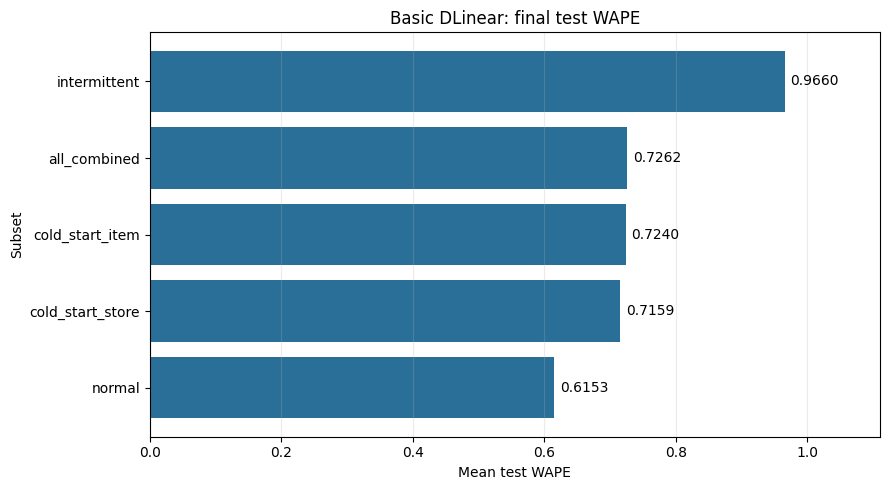

In [11]:
plot_data = final_summary.sort_values("wape_mean")

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.barh(
    plot_data["subset"],
    plot_data["wape_mean"],
    color="#2A6F97",
)

# Add the WAPE value next to each bar.
ax.bar_label(
    bars,
    fmt="%.4f",
    padding=4,
)

# Add space so the labels are not cut off.
ax.set_xlim(0, plot_data["wape_mean"].max() * 1.15)

ax.set_xlabel("Mean test WAPE")
ax.set_ylabel("Subset")
ax.set_title(f"{MODEL_NAME}: final test WAPE")
ax.grid(axis="x", alpha=0.25)

plt.tight_layout()
plt.show()

In [12]:
final_metrics_df.groupby("subset")["seed"].nunique()

subset
all_combined        5
cold_start_item     5
cold_start_store    5
intermittent        5
normal              5
Name: seed, dtype: int64

## Final notes